In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def plot_hosts(file_path):
    gl_colors = {
        "unavailable:": 'black',
        "idle:": 'red', 
        "busy:Project1": 'green',
        "busy:Project2": 'blue'
    }

    file_to_read = f"{file_path}/execute_stat_80.csv"
    
    try:
        df = pd.read_csv(file_to_read)
    except FileNotFoundError:
        print(f"Ошибка: Файл не найден. Убедитесь, что {file_to_read} существует.")
        return

    if df.empty:
        print("Нет данных для анализа и построения графика.")
        return

    df['group'] = df['client'].str[1]
    df['interval'] = df['end'] - df['start']

    time_by_type = (
        df.groupby(['client', 'group', 'type'])['interval']
        .sum()
        .unstack(level='type', fill_value=0)
        .reset_index()
    )

    busy_columns = [col for col in time_by_type.columns if col.startswith('busy:')]
    time_by_type['busy_time'] = time_by_type[busy_columns].sum(axis=1)
    time_by_type['idle_time'] = time_by_type.get('idle:', 0)
    time_by_type['unavailable_time'] = time_by_type.get('unavailable:', 0)

    time_by_type['total_time'] = time_by_type['busy_time'] + time_by_type['idle_time'] + time_by_type['unavailable_time']
    time_by_type['active_time'] = time_by_type['total_time'] - time_by_type['unavailable_time']

    time_by_type['mean_util'] = (
        time_by_type['busy_time'] / time_by_type['active_time']
    ).fillna(0) * 100
    
    plt.figure(figsize=(10, 7))
    
    ax = sns.barplot(data=time_by_type, x='group', y='mean_util', palette='viridis', errorbar=None)
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')

    plt.xlabel("Группа хостов")
    plt.ylabel("Средняя утилизация за время активности (%)")
    plt.title("Средняя утилизация хостов по группам (относительно времени активности)")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


C:\Users\xmelo\AppData\Local\Temp\ipykernel_11052\401156935.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=time_by_type, x='group', y='mean_util', palette='viridis', errorbar=None)


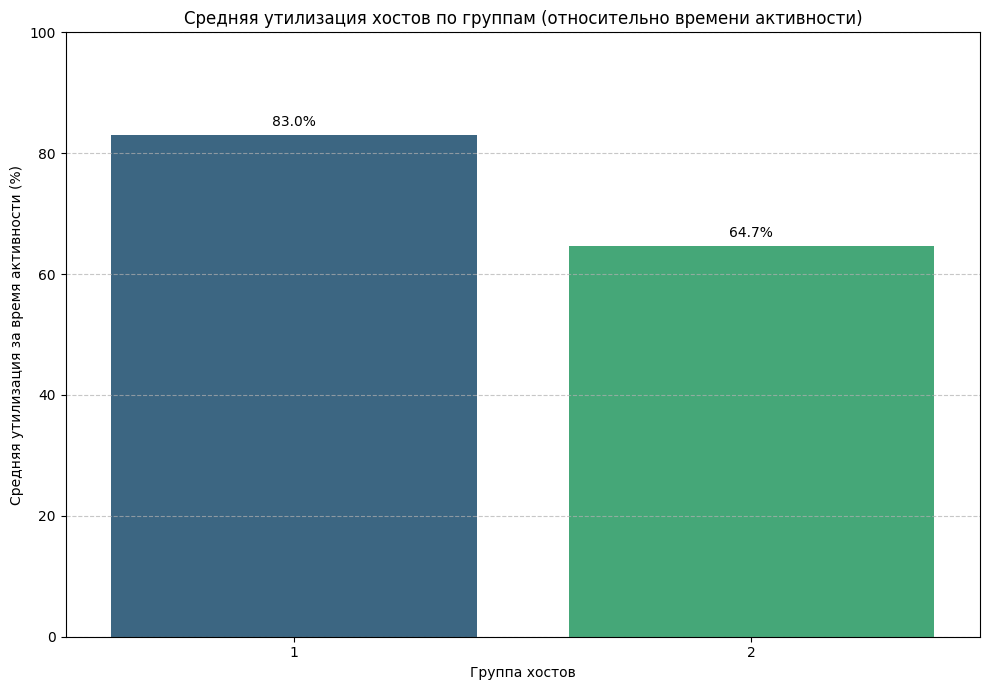

C:\Users\xmelo\AppData\Local\Temp\ipykernel_11052\401156935.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=time_by_type, x='group', y='mean_util', palette='viridis', errorbar=None)


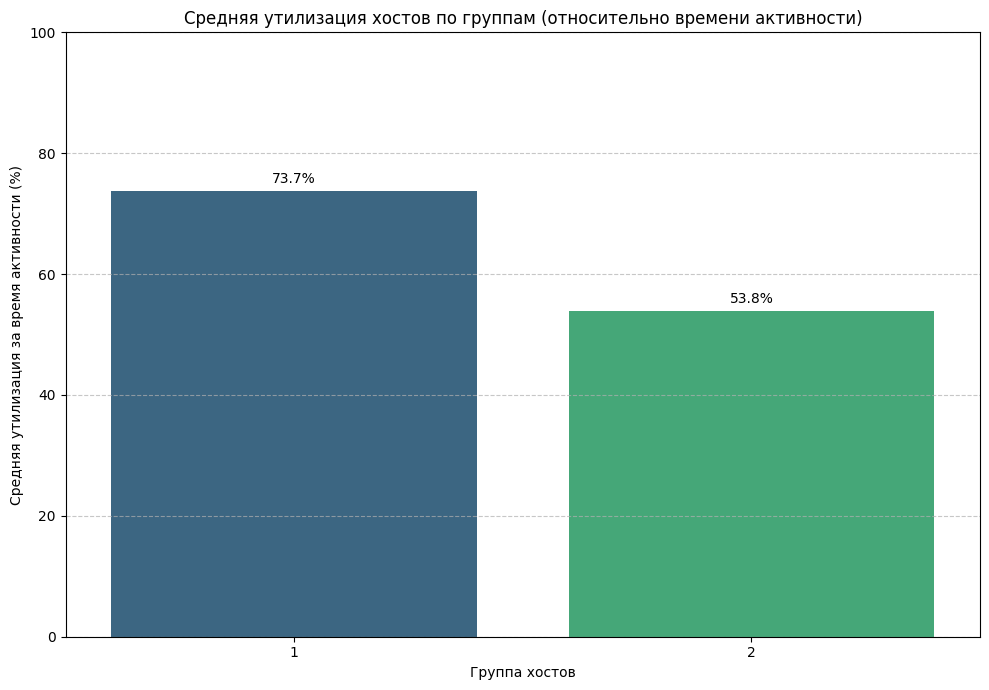

C:\Users\xmelo\AppData\Local\Temp\ipykernel_11052\401156935.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=time_by_type, x='group', y='mean_util', palette='viridis', errorbar=None)


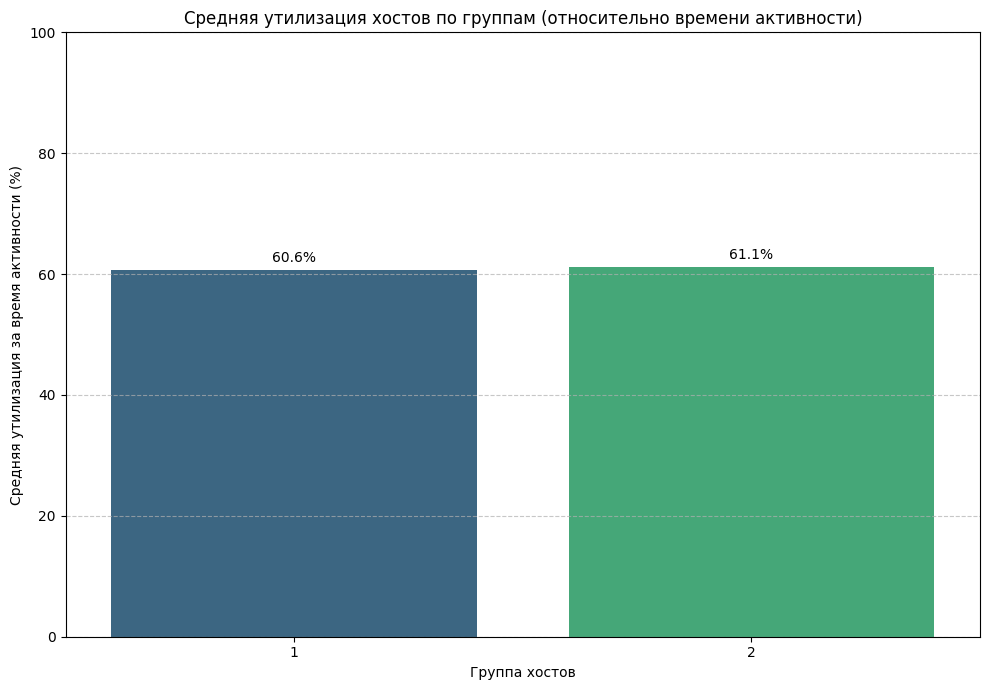

C:\Users\xmelo\AppData\Local\Temp\ipykernel_11052\401156935.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=time_by_type, x='group', y='mean_util', palette='viridis', errorbar=None)


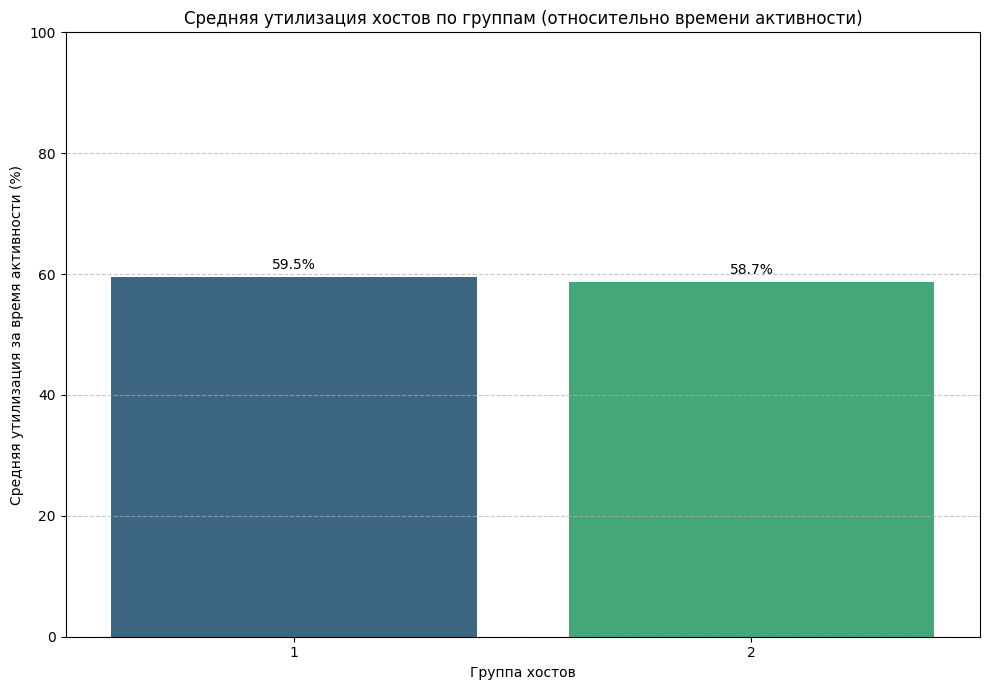

In [3]:
names = ['2025-11-15_09-40-14', '2025-11-15_09-43-55', '2025-11-15_09-47-16', '2025-11-15_09-50-08']

for name in names:
    plot_hosts(name)